# Hoja de Trabajo 6 – Task 2
**CC2017 – Modelación y Simulación, Sección 10**

- José Gerardo Ruiz García – 23719
- Gerardo André Fernández Cruz – 23763
- Juan Diego Solís Martínez – 23720

Modelo de competencia entre dos plataformas (Lotka-Volterra competitivo):

$$\dot x = r_1\,x\,(1 - x - \alpha_{12}\,y), \qquad \dot y = r_2\,y\,(1 - y - \alpha_{21}\,x)$$

En este Task 2 **sí se simula** el sistema. Los integradores (Euler y RK4) están programados desde cero; `solve_ivp` solo se usa como solución de referencia en el 2.1.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Semilla fija para reproducibilidad (requisito de la hoja)
np.random.seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

os.makedirs('img', exist_ok=True)   # carpeta de figuras

## Parámetros del grupo (igual que en el Task 1)

In [2]:
g = 5  # número de grupo

conjuntos = {1: (0.5, 0.6), 2: (1.4, 1.5), 3: (0.6, 1.5), 4: (1.5, 0.6)}
conjunto = ((g - 1) % 4) + 1
a12, a21 = conjuntos[conjunto]
r1 = 1.0
r2 = 0.5 + 0.1 * ((g - 1) % 5)

print(f"Grupo: {g}, conjunto {conjunto}: alpha12 = {a12}, alpha21 = {a21}, r1 = {r1}, r2 = {r2:.1f}")


def campo(x, y):
    # Lado derecho del sistema: (x', y')
    dx = r1 * x * (1 - x - a12 * y)
    dy = r2 * y * (1 - y - a21 * x)
    return dx, dy


def jacobiana(x, y):
    J11 = r1 * (1 - 2 * x - a12 * y)   # d(x')/dx
    J12 = -r1 * a12 * x                # d(x')/dy
    J21 = -r2 * a21 * y                # d(y')/dx
    J22 = r2 * (1 - 2 * y - a21 * x)   # d(y')/dy
    return np.array([[J11, J12], [J21, J22]])


def clasificar(tau, delta, disc, tol=1e-12):
    # Clasificación con el plano traza-determinante
    if delta < -tol:
        return 'silla'
    tipo = 'nodo' if disc >= -tol else 'foco'
    if abs(tau) < tol:
        return 'centro'
    return f"{tipo} {'estable' if tau < 0 else 'inestable'}"


def f(t, X):
    # Campo vectorizado para los integradores: X[0] = x, X[1] = y
    # (sirve para un estado, shape (2,), o para muchos a la vez, shape (2, M))
    return np.array([r1 * X[0] * (1 - X[0] - a12 * X[1]),
                     r2 * X[1] * (1 - X[1] - a21 * X[0])])

Grupo: 5, conjunto 1: alpha12 = 0.5, alpha21 = 0.6, r1 = 1.0, r2 = 0.9


In [3]:
D = 1 - a12 * a21
xs = (1 - a12) / D
ys = (1 - a21) / D
equilibrios = {'(0,0)': (0.0, 0.0), '(1,0)': (1.0, 0.0), '(0,1)': (0.0, 1.0), '(x*,y*)': (xs, ys)}
nombres_eq = list(equilibrios.keys())
eqs = np.array(list(equilibrios.values()))          # (4, 2)
xstar = np.array([xs, ys])

tipos = {}
for nombre, (px, py) in equilibrios.items():
    J = jacobiana(px, py)
    tau = np.trace(J); delta = np.linalg.det(J)
    tipos[nombre] = clasificar(tau, delta, tau**2 - 4 * delta)
    print(f"{nombre:8s} = ({px:.4f}, {py:.4f})  lambda = {np.round(np.sort(np.linalg.eigvals(J).real), 4)}  ->  {tipos[nombre]}")

lam_int = np.linalg.eigvals(jacobiana(xs, ys)).real
lam_lento = lam_int[np.argmin(np.abs(lam_int))]     # el de menor |Re|
lam_rapido = lam_int[np.argmax(np.abs(lam_int))]
T_rec = 1 / np.min(np.abs(lam_int))
print(f"\nT_rec = 1/min|Re(lambda)| = {T_rec:.4f}")

# Estados de referencia del Task 1.3
P = {'P1': (0.05, 0.05), 'P2': (0.80, 0.30), 'P3': (0.30, 0.80), 'P4': (0.60, 0.60)}

(0,0)    = (0.0000, 0.0000)  lambda = [0.9 1. ]  ->  nodo inestable
(1,0)    = (1.0000, 0.0000)  lambda = [-1.    0.36]  ->  silla
(0,1)    = (0.0000, 1.0000)  lambda = [-0.9  0.5]  ->  silla
(x*,y*)  = (0.7143, 0.5714)  lambda = [-0.961  -0.2676]  ->  nodo estable

T_rec = 1/min|Re(lambda)| = 3.7372


## Task 2.1 – Integradores y convergencia

### 2.1a – Euler y RK4 desde cero
Ambos reciben el campo `f`, el estado inicial `x0`, el paso `h` y el tiempo final `T`, y devuelven `(t, X)` con $N=\mathrm{round}(T/h)$ pasos.

- Euler: $x_{n+1} = x_n + h f(x_n)$
- RK4: $x_{n+1} = x_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$

In [4]:
def paso_euler(f, t, x, h):
    return x + h * f(t, x)


def paso_rk4(f, t, x, h):
    k1 = f(t, x)
    k2 = f(t + h / 2, x + h / 2 * k1)
    k3 = f(t + h / 2, x + h / 2 * k2)
    k4 = f(t + h, x + h * k3)
    return x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def integrar(paso, f, x0, h, T):
    N = int(round(T / h))                       # número de pasos
    x0 = np.asarray(x0, dtype=float)
    t = h * np.arange(N + 1)
    X = np.zeros((N + 1,) + x0.shape)           # X[n] = estado en t_n
    X[0] = x0
    for n in range(N):
        X[n + 1] = paso(f, t[n], X[n], h)
    return t, X


def euler(f, x0, h, T):
    return integrar(paso_euler, f, x0, h, T)


def rk4(f, x0, h, T):
    return integrar(paso_rk4, f, x0, h, T)


# Prueba rápida: ambos deben terminar cerca del equilibrio interior desde P2
for nom, met in [('Euler', euler), ('RK4', rk4)]:
    t_, X_ = met(f, P['P2'], 0.01, 40)
    print(f"{nom}: x(40) = {np.round(X_[-1], 6)}   (x*, y*) = {np.round(xstar, 6)}")

Euler: x(40) = [0.714291 0.571421]   (x*, y*) = [0.714286 0.571429]
RK4: x(40) = [0.714292 0.571421]   (x*, y*) = [0.714286 0.571429]


### 2.1b – Error contra la solución de referencia
Referencia: `solve_ivp` con `DOP853`, `rtol = atol = 1e-12`, desde $P_2$ hasta $T=10$.
Error principal $=\lVert x_h(10) - x_{ref}(10)\rVert_2$. Como columna secundaria se da el máximo del error sobre toda la malla (usando `dense_output` de la referencia).

In [5]:
T10 = 10.0
x0 = np.array(P['P2'])
ref = solve_ivp(f, (0, T10), x0, method='DOP853', rtol=1e-12, atol=1e-12, dense_output=True)
x_ref = ref.y[:, -1]
print("x_ref(10) =", x_ref)

hs = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
err = {'Euler': [], 'RK4': []}
err_max = {'Euler': [], 'RK4': []}
for nom, met in [('Euler', euler), ('RK4', rk4)]:
    for h in hs:
        t_, X_ = met(f, x0, h, T10)
        err[nom].append(np.linalg.norm(X_[-1] - x_ref))
        Xr = ref.sol(t_).T                                   # referencia en la misma malla
        err_max[nom].append(np.max(np.linalg.norm(X_ - Xr, axis=1)))
for k in err:
    err[k] = np.array(err[k]); err_max[k] = np.array(err_max[k])

print(f"{'h':>8s} | {'err Euler (T=10)':>17s} | {'err RK4 (T=10)':>15s} | {'max Euler':>11s} | {'max RK4':>11s}")
for i, h in enumerate(hs):
    print(f"{h:8.4f} | {err['Euler'][i]:17.4e} | {err['RK4'][i]:15.4e} | {err_max['Euler'][i]:11.4e} | {err_max['RK4'][i]:11.4e}")

x_ref(10) = [0.73141718 0.54917563]
       h |  err Euler (T=10) |  err RK4 (T=10) |   max Euler |     max RK4
  0.2000 |        1.3505e-03 |      3.2107e-09 |  2.5768e-03 |  3.0628e-07
  0.1000 |        6.7296e-04 |      1.9226e-10 |  1.2386e-03 |  1.7762e-08
  0.0500 |        3.3592e-04 |      1.1260e-11 |  6.0729e-04 |  1.0677e-09
  0.0250 |        1.6782e-04 |      4.6024e-13 |  3.0074e-04 |  7.1272e-11
  0.0125 |        8.3874e-05 |      6.8624e-13 |  1.4966e-04 |  6.8478e-11


### 2.1c – Orden de convergencia
Se ajusta una recta a $\log_{10}(\text{error})$ contra $\log_{10}(h)$; la pendiente es el orden observado (esperado: 1 para Euler y 4 para RK4).

Pendiente Euler (error en T=10, los 5 pasos): 1.002
Pendiente Euler (error máximo en el tiempo):   1.025
Pendiente RK4 (error en T=10, los 5 pasos): 3.309
Pendiente RK4 (error máximo en el tiempo):   3.222
Pendientes locales Euler: [1.005 1.002 1.001 1.001]
Pendientes locales RK4: [ 4.062  4.094  4.613 -0.576]

Error RK4 en h mínimo = 6.86e-13  ->  cerca del piso (~1e-12) de la referencia/redondeo: True
Pendiente RK4 usando solo los h con error > 1e-11: 4.078
Cociente error final / error máximo (RK4): [0.0105 0.0108 0.0105 0.0065 0.01  ]
Cociente error final / error máximo (Euler): [0.5241 0.5433 0.5531 0.558  0.5604]


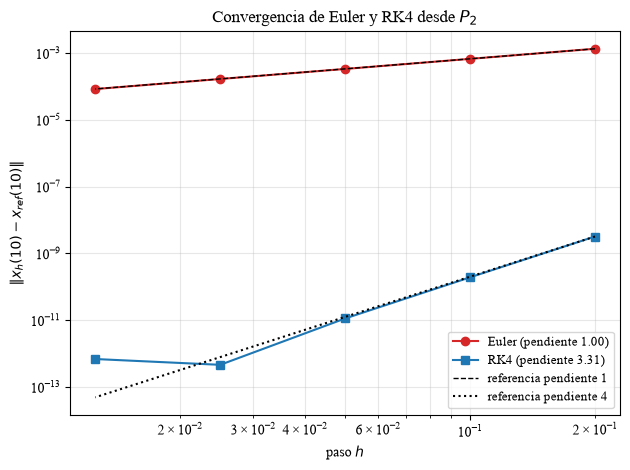

In [6]:
lh = np.log10(hs)
pend = {}
for nom in err:
    pend[nom] = np.polyfit(lh, np.log10(err[nom]), 1)[0]
    print(f"Pendiente {nom} (error en T=10, los 5 pasos): {pend[nom]:.3f}")
    print(f"Pendiente {nom} (error máximo en el tiempo):   {np.polyfit(lh, np.log10(err_max[nom]), 1)[0]:.3f}")

# Pendientes entre pasos consecutivos (para ver dónde se aplana RK4)
for nom in err:
    loc = np.diff(np.log10(err[nom])) / np.diff(lh)
    print(f"Pendientes locales {nom}:", np.round(loc, 3))

# RK4: ¿el error de h pequeño ya está cerca del piso de la referencia (~1e-12)?
piso = 1e-11
buenos = err['RK4'] > piso
print(f"\nError RK4 en h mínimo = {err['RK4'][-1]:.2e}  ->  cerca del piso (~1e-12) de la referencia/redondeo: {err['RK4'][-1] < 100 * piso}")
if buenos.sum() >= 2 and buenos.sum() < len(hs):
    p_rk4_sin = np.polyfit(lh[buenos], np.log10(err['RK4'][buenos]), 1)[0]
    print(f"Pendiente RK4 usando solo los h con error > {piso:g}: {p_rk4_sin:.3f}")
print("Cociente error final / error máximo (RK4):", np.round(err['RK4'] / err_max['RK4'], 4))
print("Cociente error final / error máximo (Euler):", np.round(err['Euler'] / err_max['Euler'], 4))

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.loglog(hs, err['Euler'], 'o-', color='tab:red', label=f"Euler (pendiente {pend['Euler']:.2f})")
ax.loglog(hs, err['RK4'], 's-', color='tab:blue', label=f"RK4 (pendiente {pend['RK4']:.2f})")
ax.loglog(hs, err['Euler'][0] * (hs / hs[0]), 'k--', lw=1, label='referencia pendiente 1')
ax.loglog(hs, err['RK4'][0] * (hs / hs[0])**4, 'k:', lw=1.5, label='referencia pendiente 4')
ax.set_xlabel('paso $h$'); ax.set_ylabel(r'$\|x_h(10) - x_{ref}(10)\|$')
ax.set_title('Convergencia de Euler y RK4 desde $P_2$')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('img/task2_convergencia.png', dpi=200)
plt.show()

**Notas 2.1.** Euler es de orden 1 y RK4 de orden 4, como se esperaba (ver pendientes). El sistema converge a un nodo estable, así que los errores acumulados se **amortiguan** con el tiempo: el error en $T=10$ puede ser menor que el máximo sobre toda la trayectoria (que ocurre en el transitorio). Con RK4 y $h$ pequeño el error se acerca al piso de la referencia ($\sim10^{-12}$) y la pendiente deja de ser 4.

## Task 2.2 – Retrato de fases

### 2.2a/b – Campo, nulclinas, trayectorias y equilibrios
Trayectorias con RK4 ($h=0.01$; $T=40$ en general y $T=60$ para $P_1$–$P_4$).

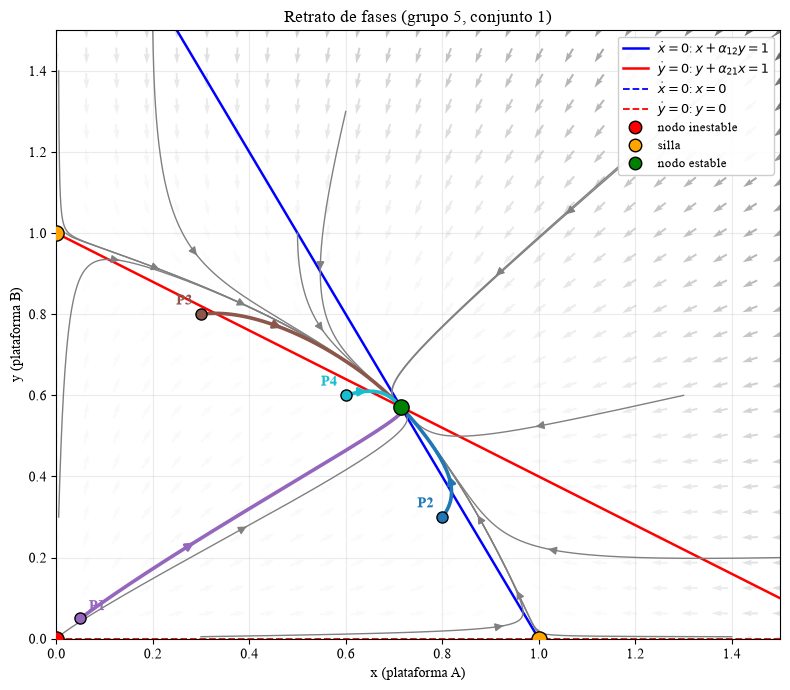

In [7]:
iniciales = [(0.005, 0.3), (0.005, 1.4), (0.3, 0.005), (1.4, 0.005), (0.01, 0.01),
             (1.5, 1.5), (1.5, 0.2), (0.2, 1.5),
             (1.0, 0.02), (0.02, 1.0), (1.3, 0.6), (0.6, 1.3), (0.5, 1.0), (1.2, 1.2)]
tray = [rk4(f, p, 0.01, 40) for p in iniciales]
tray_P = {k: rk4(f, p, 0.01, 60) for k, p in P.items()}

colP = {'P1': 'tab:purple', 'P2': 'tab:blue', 'P3': 'tab:brown', 'P4': 'tab:cyan'}
col_tipo = {'nodo inestable': 'red', 'silla': 'orange', 'nodo estable': 'green'}


def flecha(ax, X, color, lw, frac=0.5):
    # Pequeña punta de flecha en un punto de la trayectoria (por longitud de arco)
    s = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(X, axis=0), axis=1))])
    i = min(np.searchsorted(s, frac * s[-1]), len(X) - 2)
    ax.annotate('', xy=X[i + 1], xytext=X[i], arrowprops=dict(arrowstyle='-|>', color=color, lw=lw, mutation_scale=12))


fig, ax = plt.subplots(figsize=(8, 7))
# Campo vectorial normalizado (todas las flechas del mismo largo)
gx, gy = np.meshgrid(np.linspace(0, 1.5, 25), np.linspace(0, 1.5, 25))
U, V = campo(gx, gy)
mag = np.hypot(U, V); mag[mag == 0] = 1
ax.quiver(gx, gy, U / mag, V / mag, np.hypot(U, V), cmap='Greys', pivot='mid', width=0.0028, alpha=0.6)

# Nulclinas
xx = np.linspace(0, 1.5, 300)
ax.plot(xx[xx <= 1], (1 - xx[xx <= 1]) / a12, 'b', lw=1.8, label=r'$\dot x=0$: $x+\alpha_{12}y=1$')
ax.plot(xx, 1 - a21 * xx, 'r', lw=1.8, label=r'$\dot y=0$: $y+\alpha_{21}x=1$')
ax.plot([0, 0], [0, 1.5], 'b--', lw=1.3, label=r'$\dot x=0$: $x=0$')
ax.plot([0, 1.5], [0, 0], 'r--', lw=1.3, label=r'$\dot y=0$: $y=0$')

# Trayectorias generales
for (tt, X) in tray:
    ax.plot(X[:, 0], X[:, 1], color='gray', lw=1)
    flecha(ax, X, 'gray', 1)
# Trayectorias de P1..P4
for k, (tt, X) in tray_P.items():
    ax.plot(X[:, 0], X[:, 1], color=colP[k], lw=2.6, zorder=4)
    flecha(ax, X, colP[k], 2, 0.35)
    ax.plot(*P[k], 'o', color=colP[k], mec='k', ms=8, zorder=6)
    ax.annotate(k, P[k], xytext=(-18, 7) if k != 'P1' else (6, 6), textcoords='offset points',
                fontsize=11, fontweight='bold', color=colP[k], zorder=7)

# Equilibrios coloreados por tipo
for nombre, (px, py) in equilibrios.items():
    ax.plot(px, py, 'o', color=col_tipo[tipos[nombre]], mec='k', ms=11, zorder=8)

handles, labels = ax.get_legend_handles_labels()
for tp, c in col_tipo.items():
    handles.append(plt.Line2D([], [], marker='o', ls='', color=c, mec='k', ms=9)); labels.append(tp)
ax.legend(handles, labels, loc='upper right', fontsize=9, framealpha=0.95)
ax.set_xlim(0, 1.5); ax.set_ylim(0, 1.5)
ax.set_xlabel('x (plataforma A)'); ax.set_ylabel('y (plataforma B)')
ax.set_title('Retrato de fases (grupo 5, conjunto 1)')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig('img/task2_retrato_fases.png', dpi=200)
plt.show()

### 2.2c – Comparación con las predicciones del Task 1.3
Se imprimen los hechos medidos en la simulación para cada $P_i$.

In [8]:
def region(x_, y_):
    # signos de (x', y') en el punto
    dx, dy = campo(x_, y_)
    return ('+' if dx > 0 else '-') + ('+' if dy > 0 else '-')


def cruces(t_, X):
    # tiempos donde cambia el signo de x' (nulclina de x) o de y' (nulclina de y)
    g1 = 1 - X[:, 0] - a12 * X[:, 1]
    g2 = 1 - X[:, 1] - a21 * X[:, 0]
    c1 = t_[1:][np.sign(g1[1:]) != np.sign(g1[:-1])]
    c2 = t_[1:][np.sign(g2[1:]) != np.sign(g2[:-1])]
    return c1, c2


def cambios_signo(v, tol=1e-9):
    # número de cambios de signo ignorando valores minúsculos (ruido)
    s = np.sign(v[np.abs(v) > tol])
    return int(np.sum(s[1:] != s[:-1]))


print("Equilibrio interior:", np.round(xstar, 6))
for k, (tt, X) in tray_P.items():
    fin = X[-1]
    dist = np.linalg.norm(fin - xstar)
    print(f"{k} {P[k]}: estado final = {np.round(fin, 8)},  ||x(60) - x*|| = {dist:.2e},  convergió: {dist < 1e-6}")

# --- P1
tt, X = tray_P['P1']
print("\n--- P1: sale de cerca del origen")
nrm = np.linalg.norm(X, axis=1)
for lim in (0.1, 0.2, 0.3, 0.5):
    i = np.argmax(nrm > lim)
    print(f"  primer t con ||x|| > {lim}: t = {tt[i]:.2f},  y/x = {X[i,1]/X[i,0]:.3f}")
ang = np.degrees(np.arctan2(X[:, 1], X[:, 0]))
i05 = np.argmax(nrm > 0.5)
print(f"  ángulo de la trayectoria (y/x) en t=0: {ang[0]:.1f} grados; en ||x||>0.5: {ang[i05]:.1f} grados (la diagonal es 45)")
print(f"  rango del ángulo mientras ||x||<0.5: [{ang[:i05].min():.1f}, {ang[:i05].max():.1f}] grados")
c1, c2 = cruces(tt, X)
print("  cruces con nulclina de x (x'=0):", np.round(c1, 2), "  con nulclina de y (y'=0):", np.round(c2, 2))
print(f"  tiempo 'cerca del origen' (||x||<0.1): {np.sum(nrm < 0.1) * 0.01:.2f};  (max(x,y)<0.2): {np.sum(X.max(axis=1) < 0.2) * 0.01:.2f}")
print(f"  región (signos de x', y') en t=0: {region(*P['P1'])}; secuencia:", end=' ')
reg = [region(*p) for p in X[::10]]
sec = [reg[0]] + [reg[i] for i in range(1, len(reg)) if reg[i] != reg[i - 1]]
print(sec)
print(f"  distancia mínima a la silla (1,0): {np.min(np.linalg.norm(X - [1, 0], axis=1)):.3f};  a la silla (0,1): {np.min(np.linalg.norm(X - [0, 1], axis=1)):.3f}")

# --- P2
tt, X = tray_P['P2']
print("\n--- P2")
c1, c2 = cruces(tt, X)
print("  cruces con nulclina de x (sign de 1-x-a12*y):", np.round(c1, 3), "  con nulclina de y:", np.round(c2, 3))
g1 = 1 - X[:, 0] - a12 * X[:, 1]
print(f"  1-x-a12*y en t=0: {g1[0]:.3f}; después del primer cruce, ¿vuelve a cruzar? {len(c1) > 1}")
reg = [region(*p) for p in X[::5]]
sec = [(reg[0], 0.0)] + [(reg[i], round(tt[::5][i], 2)) for i in range(1, len(reg)) if reg[i] != reg[i - 1]]
print("  secuencia de regiones (signos x', y') y tiempo de entrada:", sec)
print(f"  máximo de x: {X[:,0].max():.4f} (en t = {tt[np.argmax(X[:,0])]:.2f}),  x* = {xs:.4f};  mínimo de y: {X[:,1].min():.4f}")
print(f"  monótona en x tras el pico: {cambios_signo(np.diff(X[np.argmax(X[:,0]):, 0]))==0},  y: {cambios_signo(np.diff(X[:,1]))==0}")

# --- P3
tt, X = tray_P['P3']
print("\n--- P3")
print(f"  x' en t=0: {campo(*P['P3'])[0]:.4f}, y' en t=0: {campo(*P['P3'])[1]:.4f}  (y-nulclina: 1-y-a21*x = {1-P['P3'][1]-a21*P['P3'][0]:.3f})")
print(f"  x monótona creciente: {np.all(np.diff(X[:,0]) > 0)};  y monótona decreciente: {np.all(np.diff(X[:,1]) < 0)}")
print(f"  y sube al inicio hasta y = {X[:,1].max():.4f} (t = {tt[np.argmax(X[:,1])]:.2f}) y después baja: y monótona decreciente desde ese pico: {np.all(np.diff(X[np.argmax(X[:,1]):,1]) < 0)}")
print(f"  x final - x* = {X[-1,0]-xs:.2e};  x máximo = {X[:,0].max():.4f}, y mínimo = {X[:,1].min():.4f}")
c1, c2 = cruces(tt, X)
print("  cruces con nulclinas:", np.round(c1, 3), np.round(c2, 3))

# --- P4
tt, X = tray_P['P4']
print("\n--- P4")
dX = X - xstar
V_ = np.array([campo(a_, b_) for a_, b_ in X[::10]])
print(f"  distancia inicial a x*: {np.linalg.norm(dX[0]):.4f}")
print(f"  cambios de signo en x-x*: {cambios_signo(dX[:,0])},  y-y*: {cambios_signo(dX[:,1])}")
print(f"  cambios de signo en x': {cambios_signo(V_[:,0])},  y': {cambios_signo(V_[:,1])}")
print(f"  x monótona creciente: {np.all(np.diff(X[:,0]) > 0)};  y monótona: creciente {np.all(np.diff(X[:,1]) > 0)}, decreciente {np.all(np.diff(X[:,1]) < 0)}")
print(f"  y alcanza un máximo de {X[:,1].max():.4f} en t = {tt[np.argmax(X[:,1])]:.2f} (sobrepaso de y* en {X[:,1].max()-ys:.4f}), pero nunca cruza y*: y-y* > 0 siempre: {np.all(dX[:,1] > 0)}")
print(f"  x en [{X[:,0].min():.4f}, {X[:,0].max():.4f}], y en [{X[:,1].min():.4f}, {X[:,1].max():.4f}]  (x*={xs:.4f}, y*={ys:.4f})")
c1, c2 = cruces(tt, X)
print("  cruces con nulclinas:", np.round(c1, 3), np.round(c2, 3))

Equilibrio interior: [0.714286 0.571429]
P1 (0.05, 0.05): estado final = [0.71428572 0.57142856],  ||x(60) - x*|| = 9.40e-09,  convergió: True
P2 (0.8, 0.3): estado final = [0.71428574 0.57142854],  ||x(60) - x*|| = 4.43e-08,  convergió: True
P3 (0.3, 0.8): estado final = [0.71428568 0.57142861],  ||x(60) - x*|| = 5.56e-08,  convergió: True
P4 (0.6, 0.6): estado final = [0.71428571 0.57142858],  ||x(60) - x*|| = 1.00e-08,  convergió: True

--- P1: sale de cerca del origen
  primer t con ||x|| > 0.1: t = 0.41,  y/x = 0.961
  primer t con ||x|| > 0.2: t = 1.27,  y/x = 0.890
  primer t con ||x|| > 0.3: t = 1.85,  y/x = 0.850
  primer t con ||x|| > 0.5: t = 2.79,  y/x = 0.804
  ángulo de la trayectoria (y/x) en t=0: 45.0 grados; en ||x||>0.5: 38.8 grados (la diagonal es 45)
  rango del ángulo mientras ||x||<0.5: [38.8, 45.0] grados
  cruces con nulclina de x (x'=0): [9.25]   con nulclina de y (y'=0): []
  tiempo 'cerca del origen' (||x||<0.1): 0.41;  (max(x,y)<0.2): 1.66
  región (signos d

## Task 2.3 – Cuencas de atracción
### 2.3a – Malla de 60×60 con RK4 vectorizado
Se integra toda la malla a la vez ($h=0.05$). Un estado "convergió" al equilibrio $E$ si $\lVert x-E\rVert<10^{-6}$ y $\lVert f(x)\rVert<10^{-6}$.

**Justificación de la tolerancia:** $10^{-6}$ es mucho menor que la distancia mínima entre equilibrios ($\approx 0.6$), así que no hay ambigüedad. La escala lenta es $T_{rec}=3.74$, así que desde distancia $\sim1$ se llega a $10^{-6}$ en $\approx \ln(10^6)\cdot 3.74\approx 52$; usamos $T_{max}=200$ como tope de seguridad. Lo que no converja se etiqueta "no convergió".

Pasos usados: 1223 (t = 61.15 de Tmax = 200.0)
Estados sin convergir: 0
Tiempo de convergencia: mín = 14.10, media = 47.19, máx = 61.15
El más lento: estado inicial (1.500, 0.010)
Tiempo de convergencia en las 4 esquinas de la malla: {'(0.01,0.01)': np.float64(48.2), '(1.5,0.01)': np.float64(61.2), '(0.01,1.5)': np.float64(58.0), '(1.5,1.5)': np.float64(43.8)}
Tiempo medio con y0 < 0.05 : 57.6   con y0 > 1 : 47.1


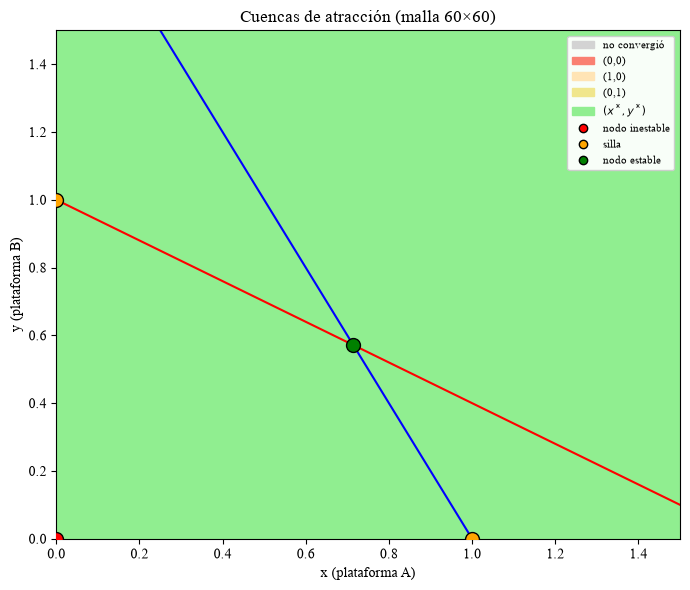

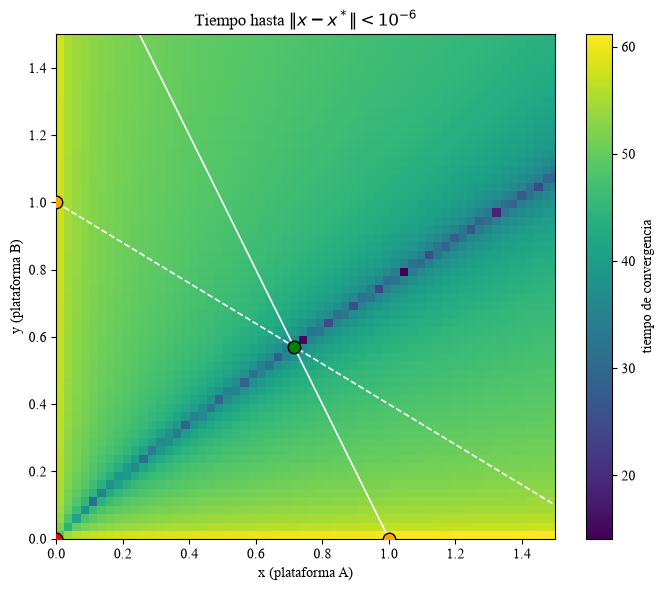

In [9]:
n = 60
h = 0.05
Tmax = 200.0
tol = 1e-6
gx = np.linspace(0.01, 1.5, n)
GX, GY = np.meshgrid(gx, gx)
X = np.array([GX.ravel(), GY.ravel()])            # (2, 3600)
M = X.shape[1]
t_conv = np.full(M, np.nan)
destino = -np.ones(M, dtype=int)                  # -1 = no convergió

pasos = int(round(Tmax / h))
for k in range(1, pasos + 1):
    X = paso_rk4(f, (k - 1) * h, X, h)
    d = np.linalg.norm(X[None, :, :] - eqs[:, :, None], axis=1)   # (4, M) distancias a los equilibrios
    j = np.argmin(d, axis=0)
    ok = (d[j, np.arange(M)] < tol) & (np.linalg.norm(f(0, X), axis=0) < tol) & np.isnan(t_conv)
    t_conv[ok] = k * h
    destino[ok] = j[ok]
    if not np.isnan(t_conv).any():
        break

print(f"Pasos usados: {k} (t = {k*h:.2f} de Tmax = {Tmax})")
print(f"Estados sin convergir: {np.sum(destino == -1)}")
print(f"Tiempo de convergencia: mín = {np.nanmin(t_conv):.2f}, media = {np.nanmean(t_conv):.2f}, máx = {np.nanmax(t_conv):.2f}")
imax = np.nanargmax(t_conv)
print(f"El más lento: estado inicial ({GX.ravel()[imax]:.3f}, {GY.ravel()[imax]:.3f})")
Tconv = t_conv.reshape(n, n)
print("Tiempo de convergencia en las 4 esquinas de la malla:",
      {c: round(Tconv[i, j_], 1) for c, (i, j_) in {'(0.01,0.01)': (0, 0), '(1.5,0.01)': (0, -1), '(0.01,1.5)': (-1, 0), '(1.5,1.5)': (-1, -1)}.items()})
print("Tiempo medio con y0 < 0.05 :", round(np.nanmean(Tconv[:2, :]), 1), "  con y0 > 1 :", round(np.nanmean(Tconv[gx > 1, :]), 1))

# Mapa de cuencas
D_ = destino.reshape(n, n)
colores = ['lightgray', 'red', 'orange', 'orange', 'green']   # -1, (0,0), (1,0), (0,1), interior
cmap = ListedColormap(['lightgray', 'salmon', 'moccasin', 'khaki', 'lightgreen'])
norm = BoundaryNorm(np.arange(-1.5, 3.6, 1), cmap.N)
fig, ax = plt.subplots(figsize=(7, 6))
ax.pcolormesh(GX, GY, D_, cmap=cmap, norm=norm, shading='nearest')
xx = np.linspace(0, 1.5, 300)
ax.plot(xx[xx <= 1], (1 - xx[xx <= 1]) / a12, 'b', lw=1.5)
ax.plot(xx, 1 - a21 * xx, 'r', lw=1.5)
for nombre, (px, py) in equilibrios.items():
    ax.plot(px, py, 'o', color=col_tipo[tipos[nombre]], mec='k', ms=10, zorder=5)
leyenda = [Patch(color=cmap(norm(i)), label=l) for i, l in
           [(-1, 'no convergió'), (0, '(0,0)'), (1, '(1,0)'), (2, '(0,1)'), (3, r'$(x^*,y^*)$')]]
leyenda += [plt.Line2D([], [], marker='o', ls='', color=c, mec='k', label=tp) for tp, c in col_tipo.items()]
ax.legend(handles=leyenda, loc='upper right', fontsize=8, framealpha=0.95)
ax.set_xlim(0, 1.5); ax.set_ylim(0, 1.5)
ax.set_xlabel('x (plataforma A)'); ax.set_ylabel('y (plataforma B)')
ax.set_title('Cuencas de atracción (malla 60×60)')
fig.tight_layout()
fig.savefig('img/task2_cuencas.png', dpi=200)
plt.show()

# Mapa de tiempo de convergencia
fig, ax = plt.subplots(figsize=(7, 6))
pc = ax.pcolormesh(GX, GY, Tconv, cmap='viridis', shading='nearest')
fig.colorbar(pc, ax=ax, label='tiempo de convergencia')
ax.plot(xx[xx <= 1], (1 - xx[xx <= 1]) / a12, 'w', lw=1.2)
ax.plot(xx, 1 - a21 * xx, 'w--', lw=1.2)
for nombre, (px, py) in equilibrios.items():
    ax.plot(px, py, 'o', color=col_tipo[tipos[nombre]], mec='k', ms=9, zorder=5)
ax.set_xlim(0, 1.5); ax.set_ylim(0, 1.5)
ax.set_xlabel('x (plataforma A)'); ax.set_ylabel('y (plataforma B)')
ax.set_title(r'Tiempo hasta $\|x-x^*\|<10^{-6}$')
fig.tight_layout()
fig.savefig('img/task2_tiempo_convergencia.png', dpi=200)
plt.show()

### 2.3b – Fracción de la malla por equilibrio

In [10]:
for j, nombre in enumerate(nombres_eq):
    print(f"{nombre:8s}: {100 * np.mean(destino == j):6.2f} %   ({np.sum(destino == j)} puntos)")
print(f"no convergió: {100 * np.mean(destino == -1):6.2f} %")

(0,0)   :   0.00 %   (0 puntos)
(1,0)   :   0.00 %   (0 puntos)
(0,1)   :   0.00 %   (0 puntos)
(x*,y*) : 100.00 %   (3600 puntos)
no convergió:   0.00 %


### 2.3c
No aplica: el sistema tiene **un solo equilibrio estable** (el interior), así que no hay varias cuencas que comparar ni frontera entre cuencas.

### 2.3d – Notas para el informe
- El mapa es **uniforme** porque el único atractor del cuadrante abierto es $(x^*,y^*)$; todos los estados con $x_0,y_0>0$ terminan ahí.
- Los **ejes son invariantes**: en $x=0$ la dinámica es $\dot y = r_2 y(1-y)$ y va a $(0,1)$; en $y=0$ va a $(1,0)$.
- Las variedades estables de las sillas $(1,0)$ y $(0,1)$ son **exactamente los ejes**, así que no atraen nada del interior. Como la malla empieza en $0.01$, ningún estado inicial está sobre un eje.
- El origen es un nodo inestable: repele todo.
- Cerca de los ejes y de las sillas la convergencia es **más lenta** (el estado se pega a la silla antes de salir): se ve en el mapa de tiempos.

Evidencia numérica de la dinámica en los ejes:

In [11]:
for nom, p0 in [('(0, 0.5)', (0, 0.5)), ('(0.5, 0)', (0.5, 0)), ('(1e-8, 0.5)', (1e-8, 0.5)), ('(0.5, 1e-8)', (0.5, 1e-8))]:
    tt, Xa = rk4(f, p0, 0.05, 250)
    dist_a = np.linalg.norm(Xa[:, None, :] - eqs[None], axis=2)      # (N, 4)
    jfin = np.argmin(dist_a[-1])
    print(f"{nom:12s}: x(250) = ({Xa[-1,0]:.6f}, {Xa[-1,1]:.6f})  ->  más cercano {nombres_eq[jfin]}, dist = {dist_a[-1, jfin]:.2e}")
    if p0[0] > 0 and p0[0] < 1e-6 or p0[1] > 0 and p0[1] < 1e-6:
        saddle = 2 if p0[0] < 1e-6 else 1
        cerca = dist_a[:, saddle] < 0.1
        t_cerca = tt[cerca]
        print(f"      tiempo cerca de la silla {nombres_eq[saddle]} (dist < 0.1): de t = {t_cerca.min():.1f} a t = {t_cerca.max():.1f}  (≈ {t_cerca.max()-t_cerca.min():.1f} unidades)")
        print(f"      primer t con dist al interior < 1e-3: {tt[np.argmax(dist_a[:, 3] < 1e-3)]:.1f}")
print(f"Estimación teórica de la salida de (1e-8, 0.5) de (0,1): ln(0.1/1e-8)/0.5 = {np.log(0.1/1e-8)/0.5:.1f}")

(0, 0.5)    : x(250) = (0.000000, 1.000000)  ->  más cercano (0,1), dist = 1.22e-15
(0.5, 0)    : x(250) = (1.000000, 0.000000)  ->  más cercano (1,0), dist = 1.11e-15


(1e-8, 0.5) : x(250) = (0.714286, 0.571429)  ->  más cercano (x*,y*), dist = 5.59e-15
      tiempo cerca de la silla (0,1) (dist < 0.1): de t = 2.5 a t = 31.6  (≈ 29.2 unidades)
      primer t con dist al interior < 1e-3: 58.6


(0.5, 1e-8) : x(250) = (0.714286, 0.571429)  ->  más cercano (x*,y*), dist = 5.76e-15
      tiempo cerca de la silla (1,0) (dist < 0.1): de t = 2.2 a t = 44.1  (≈ 41.9 unidades)
      primer t con dist al interior < 1e-3: 72.1
Estimación teórica de la salida de (1e-8, 0.5) de (0,1): ln(0.1/1e-8)/0.5 = 32.2


## Task 2.4 – Estabilidad lineal y paso máximo de Euler

### 2.4a – Perturbaciones de $x^*$
Se perturba $x^*$ en $10^{-4}$ en 8 direcciones $\theta_k=k\pi/4$ y se simula con RK4 ($h=0.01$, $T=60$). Se ajusta una recta a $\ln\lVert x(t)-x^*\rVert$ contra $t$ en la ventana donde la norma pasa de $10^{-4}$ a $10^{-6}$ (tasa $=-$pendiente).

min|Re lambda| = 0.2676,  max|Re lambda| = 0.9610


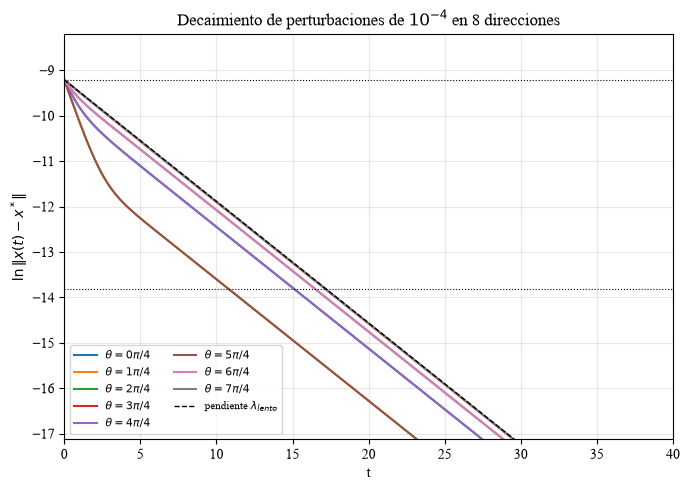

In [12]:
hh, TT = 0.01, 60.0
eps = 1e-4
thetas = np.arange(8) * np.pi / 4
res = []
for th in thetas:
    d0 = eps * np.array([np.cos(th), np.sin(th)])
    tt, Xp = rk4(f, xstar + d0, hh, TT)
    nr = np.linalg.norm(Xp - xstar, axis=1)
    res.append((tt, nr))

def tasa(tt, nr, mask):
    return -np.polyfit(tt[mask], np.log(nr[mask]), 1)[0]

lam_s = abs(lam_lento); lam_f = abs(lam_rapido)
print(f"min|Re lambda| = {lam_s:.4f},  max|Re lambda| = {lam_f:.4f}")
ventanas = {}
fig, ax = plt.subplots(figsize=(7, 5))
for th, (tt, nr) in zip(thetas, res):
    m_main = (nr <= eps * (1 + 1e-9)) & (nr >= 1e-6)
    m_late = (nr <= 1e-5) & (nr >= 1e-6)
    m_trans = tt <= 1.0
    ventanas[th] = (tasa(tt, nr, m_main), tasa(tt, nr, m_late), tasa(tt, nr, m_trans))
    ax.plot(tt, np.log(nr), label=rf'$\theta={int(round(th/(np.pi/4)))}\pi/4$')
ax.axhline(np.log(1e-4), color='k', ls=':', lw=0.8); ax.axhline(np.log(1e-6), color='k', ls=':', lw=0.8)
tt0 = np.linspace(0, 30, 50)
ax.plot(tt0, np.log(eps) - lam_s * tt0, 'k--', lw=1, label=r'pendiente $\lambda_{lento}$')
ax.set_xlim(0, 40); ax.set_ylim(np.log(1e-7) - 1, np.log(1e-4) + 1)
ax.set_xlabel('t'); ax.set_ylabel(r'$\ln\|x(t)-x^*\|$')
ax.set_title('Decaimiento de perturbaciones de $10^{-4}$ en 8 direcciones')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('img/task2_decaimiento.png', dpi=200)
plt.show()

### 2.4b – Tasas medidas y descomposición en la base de vectores propios

In [13]:
J_int = jacobiana(xs, ys)
w, Vv = np.linalg.eig(J_int)
w = np.real(w).astype(float); Vv = np.real(Vv).astype(float)
i_s = np.argmin(np.abs(w.real)); i_f = np.argmax(np.abs(w.real))
v_s = Vv[:, i_s]; v_f = Vv[:, i_f]
ang_s = np.degrees(np.arctan2(v_s[1], v_s[0])) % 180
ang_f = np.degrees(np.arctan2(v_f[1], v_f[0])) % 180
print(f"v_lento (lambda={w[i_s].real:.4f}) = {np.round(v_s, 4)}, ángulo = {ang_s:.2f} grados (mod 180)")
print(f"v_rápido (lambda={w[i_f].real:.4f}) = {np.round(v_f, 4)}, ángulo = {ang_f:.2f} grados (mod 180)")
print(f"ángulo entre los vectores propios: {abs(ang_s - ang_f):.2f} grados (no son ortogonales: J no es simétrica)")

B = np.column_stack([v_s, v_f])
print(f"\n{'theta':>6s} | {'tasa (1e-4..1e-6)':>17s} | {'err rel':>8s} | {'tasa tardía':>11s} | {'err rel':>8s} | {'tasa t<=1':>9s} | {'c_lento':>8s} | {'c_rápido':>8s} | {'t* cruce':>8s}")
for th in thetas:
    d0 = np.array([np.cos(th), np.sin(th)])
    c = np.linalg.solve(B, d0)                      # d0 = c_s v_s + c_f v_f
    tr_m, tr_l, tr_t = ventanas[th]
    # tiempo en que las dos componentes (en norma) se igualan: |c_f| e^{-lam_f t} = |c_s| e^{-lam_s t}
    tcruce = np.log(abs(c[1] * np.linalg.norm(v_f)) / abs(c[0] * np.linalg.norm(v_s))) / (lam_f - lam_s) if abs(c[0]) > 1e-12 else np.inf
    print(f"{int(round(np.degrees(th))):5d}° | {tr_m:17.4f} | {100*abs(tr_m-lam_s)/lam_s:7.2f}% | {tr_l:11.4f} | {100*abs(tr_l-lam_s)/lam_s:7.3f}% | {tr_t:9.4f} | {c[0]:8.4f} | {c[1]:8.4f} | {tcruce:8.2f}")

v_lento (lambda=-0.2676) = [ 0.6245 -0.7811], ángulo = 128.64 grados (mod 180)
v_rápido (lambda=-0.9610) = [-0.8228 -0.5684], ángulo = 34.64 grados (mod 180)
ángulo entre los vectores propios: 94.01 grados (no son ortogonales: J no es simétrica)

 theta | tasa (1e-4..1e-6) |  err rel | tasa tardía |  err rel | tasa t<=1 |  c_lento | c_rápido | t* cruce
    0° |            0.2811 |    5.04% |      0.2677 |   0.033% |    0.6052 |   0.5697 |  -0.7830 |     0.46
   45° |            0.3721 |   39.08% |      0.2774 |   3.671% |    0.9272 |  -0.1803 |  -0.9963 |     2.46
   90° |            0.2701 |    0.94% |      0.2676 |   0.006% |    0.4145 |  -0.8248 |  -0.6260 |    -0.40
  135° |            0.2679 |    0.10% |      0.2676 |   0.001% |    0.2759 |  -0.9861 |   0.1110 |    -3.15
  180° |            0.2811 |    5.04% |      0.2677 |   0.033% |    0.6051 |  -0.5697 |   0.7830 |     0.46
  225° |            0.3721 |   39.07% |      0.2774 |   3.670% |    0.9271 |   0.1803 |   0.9963 |     2.

**Interpretación.** La tasa en la ventana $10^{-4}\to10^{-6}$ queda entre $0.2676$ y un poco más, según la dirección: la componente rápida ($e^{-0.961t}$) todavía pesa durante el transitorio. Las direcciones cercanas a $v_{rápido}$ (ángulo $\approx 34.6^\circ$, o sea $\theta=45^\circ$ y $225^\circ$) tienen casi todo su peso en el modo rápido, decaen más rápido al principio (tasa alta en $t\le1$) y tardan más en que el modo lento tome el control, por eso su tasa en la ventana principal tiene el mayor error. Las direcciones cercanas a $v_{lento}$ ($\theta=135^\circ$, $315^\circ$) dan la tasa lenta casi exacta. En la ventana tardía ($10^{-5}\to10^{-6}$) todas dan $\approx0.2676$. (La columna $t^*$ es el tiempo en que se igualan las dos componentes; si sale negativo, el modo lento ya domina desde $t=0$.)

### 2.4c – Paso máximo de Euler (a mano)
Para $\dot x=\lambda x$ Euler da $x_{n+1}=(1+h\lambda)x_n$, estable si $|1+h\lambda|<1$. Con $\lambda=a+ib$:
$$|1+h\lambda|^2=(1+ha)^2+(hb)^2<1 \iff 2ha+h^2(a^2+b^2)<0 \iff h<\frac{-2a}{|\lambda|^2}\quad(a<0).$$
Si $\lambda$ es real ($b=0$): $h<\dfrac{2}{|\lambda|}$. Se pide esto para **ambos** valores propios y se toma el más restrictivo.

In [14]:
hmax_l = -2 * lam_int.real / np.abs(lam_int)**2       # para cada valor propio (sirve también si fueran complejos)
for l_, hm in zip(lam_int, hmax_l):
    print(f"lambda = {l_:.4f}: h < {hm:.4f}")
h_max_teo = hmax_l.min()
print(f"h_max teórico (el más restrictivo) = {h_max_teo:.4f}")
print(f"1 + h*lambda_rápido < 0 cuando h > 1/|lambda_rápido| = {1/lam_f:.4f}  (oscilación de periodo 2)")

lambda = -0.9610: h < 2.0812
lambda = -0.2676: h < 7.4744
h_max teórico (el más restrictivo) = 2.0812
1 + h*lambda_rápido < 0 cuando h > 1/|lambda_rápido| = 1.0406  (oscilación de periodo 2)


### 2.4d – Bisección numérica de $h_{max}$
Se dice que Euler "converge" si tras $N=4000$ pasos $\lVert x-x^*\rVert<10^{-8}$ y el estado es finito. Se hace bisección en $[1.5,3.0]$ (tolerancia $10^{-6}$) desde un estado cercano y desde $P_2$ y $P_1$ (lejanos). Para comprobar que el indicador sea monótono en $h$ también se hace un barrido.

In [15]:
import math


def euler_conv(h, x0, N=4000, tol=1e-8):
    # Euler con floats escalares; devuelve (converge, hubo_negativos, estado_final)
    x_, y_ = x0
    neg = False
    for _ in range(N):
        dx, dy = campo(x_, y_)
        x_ += h * dx; y_ += h * dy
        if not (math.isfinite(x_) and math.isfinite(y_)) or abs(x_) > 1e6 or abs(y_) > 1e6:
            return False, neg, (x_, y_)
        if x_ < 0 or y_ < 0:
            neg = True
    return math.hypot(x_ - xs, y_ - ys) < tol, neg, (x_, y_)


def biseccion(ok, lo, hi, tol=1e-6):
    # lo debe "converger" y hi no; devuelve el h más grande que converge
    if not ok(lo) or ok(hi):
        return None
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        if ok(mid): lo = mid
        else: hi = mid
    return lo


inicios = {'cercano': tuple(xstar + 1e-3 * np.array([1, 1]) / np.sqrt(2)), 'P2': P['P2'], 'P1': P['P1']}
h_scan = np.round(np.arange(0.05, 3.0001, 0.01), 4)
for nom, p0 in inicios.items():
    ok = lambda hv, p0=p0: euler_conv(hv, p0)[0]
    hb = biseccion(ok, 1.5, 3.0)
    flags = np.array([ok(hv) for hv in h_scan])
    # primer h (barrido hacia arriba) que falla y tramos de convergencia
    primer_fallo = h_scan[np.argmax(~flags)] if (~flags).any() else None
    cambios = [(h_scan[i], bool(flags[i])) for i in range(len(flags)) if i == 0 or flags[i] != flags[i - 1]]
    print(f"\nInicio {nom} {np.round(p0, 4)}:")
    print(f"  ok(1.5) = {ok(1.5)}, ok(3.0) = {ok(3.0)}")
    print(f"  bisección en [1.5, 3.0]: h_max = {hb}")
    print(f"  barrido (paso 0.01): primer h que falla = {primer_fallo}; cambios del indicador (h, converge): {cambios}")


Inicio cercano [0.715  0.5721]:
  ok(1.5) = True, ok(3.0) = False
  bisección en [1.5, 3.0]: h_max = 2.0781962871551514
  barrido (paso 0.01): primer h que falla = 2.08; cambios del indicador (h, converge): [(np.float64(0.05), True), (np.float64(2.08), False)]



Inicio P2 [0.8 0.3]:
  ok(1.5) = True, ok(3.0) = False
  bisección en [1.5, 3.0]: h_max = 2.0773565769195557
  barrido (paso 0.01): primer h que falla = 2.08; cambios del indicador (h, converge): [(np.float64(0.05), True), (np.float64(2.08), False)]



Inicio P1 [0.05 0.05]:
  ok(1.5) = True, ok(3.0) = False
  bisección en [1.5, 3.0]: h_max = 2.0773744583129883
  barrido (paso 0.01): primer h que falla = 2.08; cambios del indicador (h, converge): [(np.float64(0.05), True), (np.float64(2.08), False)]


In [16]:
# Más detalle: el h_max numérico depende de N (cerca del límite la convergencia es muy lenta)
p0 = inicios['cercano']
for Nn in (4000, 40000, 400000):
    hb = biseccion(lambda hv: euler_conv(hv, p0, N=Nn)[0], 1.5, 3.0)
    print(f"Inicio cercano, N = {Nn:6d}: h_max numérico = {hb:.6f}   (teoría {h_max_teo:.6f})")

# Comportamiento de los estados lejanos justo por encima de su h_max
for nom in ('P2', 'P1'):
    p0 = inicios[nom]
    for hv in (1.9, 2.0, 2.05, 2.1, 2.5, 3.0):
        c, neg, fin = euler_conv(hv, p0)
        print(f"{nom}, h = {hv}: converge = {c}, pasó por valores negativos = {neg}, estado tras 4000 pasos = ({fin[0]:.4g}, {fin[1]:.4g})")

Inicio cercano, N =   4000: h_max numérico = 2.078196   (teoría 2.081186)


Inicio cercano, N =  40000: h_max numérico = 2.080887   (teoría 2.081186)


Inicio cercano, N = 400000: h_max numérico = 2.081156   (teoría 2.081186)
P2, h = 1.9: converge = True, pasó por valores negativos = False, estado tras 4000 pasos = (0.7143, 0.5714)
P2, h = 2.0: converge = True, pasó por valores negativos = False, estado tras 4000 pasos = (0.7143, 0.5714)
P2, h = 2.05: converge = True, pasó por valores negativos = False, estado tras 4000 pasos = (0.7143, 0.5714)
P2, h = 2.1: converge = False, pasó por valores negativos = False, estado tras 4000 pasos = (0.6606, 0.5353)
P2, h = 2.5: converge = False, pasó por valores negativos = False, estado tras 4000 pasos = (0.4433, 0.385)
P2, h = 3.0: converge = False, pasó por valores negativos = True, estado tras 4000 pasos = (-1.435e+08, 5.328e+06)
P1, h = 1.9: converge = True, pasó por valores negativos = False, estado tras 4000 pasos = (0.7143, 0.5714)
P1, h = 2.0: converge = True, pasó por valores negativos = False, estado tras 4000 pasos = (0.7143, 0.5714)
P1, h = 2.05: converge = True, pasó por valores negat

In [17]:
# Oscilación de periodo 2 justo por debajo de h_max (signos de la perturbación)
hv = 0.98 * h_max_teo
x_, y_ = inicios['cercano']
signos = []
for _ in range(10):
    dx, dy = campo(x_, y_)
    x_ += hv * dx; y_ += hv * dy
    signos.append((int(np.sign(x_ - xs)), int(np.sign(y_ - ys))))
print(f"h = {hv:.3f}: 1 + h*lambda_rápido = {1 + hv * lam_rapido:.4f} (negativo, módulo < 1)")
print("signos de (x-x*, y-y*) en los primeros 10 pasos:", signos)

h = 2.040: 1 + h*lambda_rápido = -0.9600 (negativo, módulo < 1)
signos de (x-x*, y-y*) en los primeros 10 pasos: [(-1, -1), (1, 1), (-1, -1), (1, 1), (-1, -1), (1, 1), (-1, -1), (1, 1), (-1, -1), (1, 1)]


**Notas 2.4d.** Desde un estado cercano el $h_{max}$ numérico coincide con el teórico $2/|\lambda_{rápido}|$ (ligeramente por debajo si $N$ es chico, porque cerca del límite $|1+h\lambda|\approx1$ y la convergencia es lentísima). Desde $P_1$ y $P_2$ el valor obtenido es prácticamente el mismo (diferencia de orden $10^{-3}$, por $N$ finito): aquí el $h_{max}$ lineal también controla la convergencia global, porque la trayectoria de Euler termina entrando a la zona lineal. La linealización no dice qué pasa **por encima** de $h_{max}$: para $h$ un poco mayor Euler cae en un ciclo de periodo 2 acotado, y para $h=3$ se sale del cuadrante positivo y diverge. Para $1/0.961 \approx 1.04 < h < h_{max}$ la convergencia es **oscilatoria** (el factor $1+h\lambda_{rápido}$ es negativo).

## Task 2.5 – Campaña y robustez

Plataforma de interés: la que tiene **menos usuarios** en el equilibrio interior, $y^*=4/7<x^*=5/7$, o sea la plataforma B ($y$). El parámetro de rivalidad que frena a B es $\alpha_{21}$.

### 2.5a – Campaña: $y_0 \to y_0+\Delta$ desde $P_2$

In [18]:
def destino_de(x_final):
    d_ = np.linalg.norm(eqs - x_final, axis=1)
    return int(np.argmin(d_)), d_.min()

deltas = np.unique(np.concatenate([np.logspace(-2, np.log10(5), 25), np.linspace(0.01, 5, 25)]))
X0 = np.array([np.full_like(deltas, P['P2'][0]), P['P2'][1] + deltas])      # (2, M), todos a la vez
tt, Xd = rk4(f, X0, 0.05, 150)
dest = [destino_de(Xd[-1][:, i]) for i in range(len(deltas))]
print(f"{len(deltas)} valores de Delta entre {deltas.min():.3f} y {deltas.max():.3f}")
print("Destinos distintos:", sorted(set(nombres_eq[d_[0]] for d_ in dest)))
print(f"Máxima distancia final a (x*,y*): {max(d_[1] for d_ in dest):.2e}")
print("Indicador 'destino = interior' para todos los Delta:", all(d_[0] == 3 for d_ in dest),
      " -> no hay cambio de signo, la bisección en Delta no tiene sentido (no existe Delta crítico).")

49 valores de Delta entre 0.010 y 5.000
Destinos distintos: ['(x*,y*)']
Máxima distancia final a (x*,y*): 5.76e-15
Indicador 'destino = interior' para todos los Delta: True  -> no hay cambio de signo, la bisección en Delta no tiene sentido (no existe Delta crítico).


**Ingredientes de la prueba** de que ningún $\Delta>0$ cambia el destino:

1. El único equilibrio estable es el interior $(5/7,4/7)$ (nodo estable); $(0,0)$ es nodo inestable y $(1,0)$, $(0,1)$ son sillas.
2. Los ejes son invariantes y son las variedades estables de las sillas; el origen repele. Por tanto nada del cuadrante abierto converge a ellos.
3. Las trayectorias son acotadas: se meten en el rectángulo $[0,\max(1,x_0)]\times[0,\max(1,y_0)]$.
4. Criterio de Dulac con $B=1/(xy)$: $\nabla\cdot(B f, B g)=\dfrac{\partial}{\partial x}\Big(\dfrac{r_1(1-x-\alpha_{12}y)}{y}\Big)+\dfrac{\partial}{\partial y}\Big(\dfrac{r_2(1-y-\alpha_{21}x)}{x}\Big)=-\dfrac{r_1}{y}-\dfrac{r_2}{x}<0$ en el cuadrante abierto $\Rightarrow$ no hay órbitas periódicas.
5. Poincaré–Bendixson: una trayectoria acotada sin órbitas periódicas ni ciclos heteroclínicos converge a un equilibrio; el único posible es $(5/7,4/7)$. Esto coincide con el mapa de cuencas del 2.3 (100 % al interior).

Delta = 0.5: máxima diferencia en y = 0.5000 (t = 0.00)
Tiempo en que el efecto cae (para siempre) por debajo del 1 % de Delta: t = 16.43 = 4.40 T_rec
Diferencia en t = T_rec: 0.1461,  en t = 2 T_rec: 0.0545
Comparación con exp(-t/T_rec) * dif(0): en t_1pct sería 0.0062


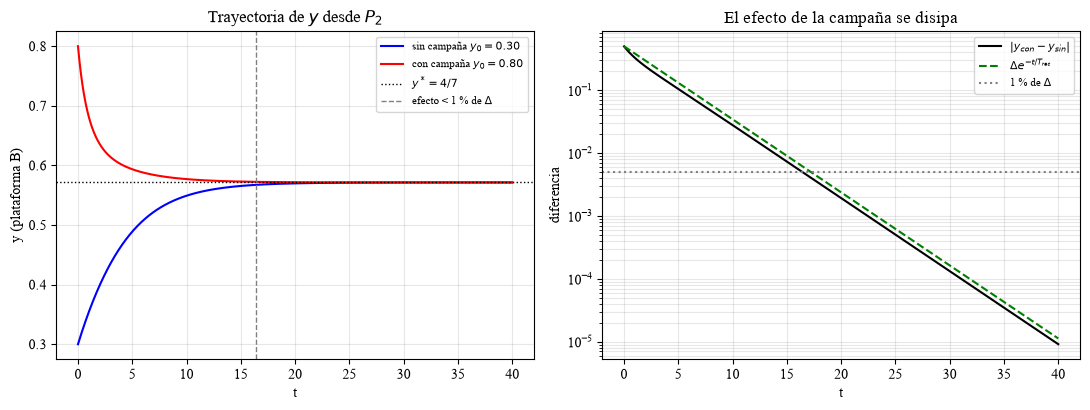

In [19]:
# Efecto de la campaña en el tiempo: P2 con y sin Delta = 0.5
Dl = 0.5
t0, X_sin = rk4(f, P['P2'], 0.01, 40)
t1, X_con = rk4(f, (P['P2'][0], P['P2'][1] + Dl), 0.01, 40)
dif = np.abs(X_con[:, 1] - X_sin[:, 1])
# primer tiempo a partir del cual la diferencia queda por debajo del 1 % de Delta
excede = np.where(dif >= 0.01 * Dl)[0]
t_1pct = t0[excede[-1] + 1]
print(f"Delta = {Dl}: máxima diferencia en y = {dif.max():.4f} (t = {t0[np.argmax(dif)]:.2f})")
print(f"Tiempo en que el efecto cae (para siempre) por debajo del 1 % de Delta: t = {t_1pct:.2f} = {t_1pct/T_rec:.2f} T_rec")
print(f"Diferencia en t = T_rec: {dif[int(round(T_rec/0.01))]:.4f},  en t = 2 T_rec: {dif[int(round(2*T_rec/0.01))]:.4f}")
print(f"Comparación con exp(-t/T_rec) * dif(0): en t_1pct sería {Dl*np.exp(-t_1pct/T_rec):.4f}")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
axs[0].plot(t0, X_sin[:, 1], 'b', label=r'sin campaña $y_0=0.30$')
axs[0].plot(t1, X_con[:, 1], 'r', label=rf'con campaña $y_0={0.3+Dl:.2f}$')
axs[0].axhline(ys, color='k', ls=':', lw=1, label=r'$y^*=4/7$')
axs[0].axvline(t_1pct, color='gray', ls='--', lw=1, label='efecto < 1 % de $\\Delta$')
axs[0].set_xlabel('t'); axs[0].set_ylabel('y (plataforma B)'); axs[0].set_title('Trayectoria de $y$ desde $P_2$')
axs[0].legend(fontsize=8); axs[0].grid(alpha=0.3)
axs[1].semilogy(t0[1:], dif[1:], 'k', label=r'$|y_{con}-y_{sin}|$')
axs[1].semilogy(t0, Dl * np.exp(-t0 / T_rec), 'g--', label=r'$\Delta e^{-t/T_{rec}}$')
axs[1].axhline(0.01 * Dl, color='gray', ls=':', label=r'1 % de $\Delta$')
axs[1].set_xlabel('t'); axs[1].set_ylabel('diferencia'); axs[1].set_title('El efecto de la campaña se disipa')
axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('img/task2_campana.png', dpi=200)
plt.show()

### 2.5b – Valor crítico de $\alpha_{21}$
Con SymPy se deriva $y^*(\alpha_{21})$, el valor propio en $(1,0)$ y el determinante en el interior.

In [20]:
A21, A12s, R1s, R2s = sp.symbols('alpha21 alpha12 r1 r2', positive=True)
Dsym = 1 - A12s * A21
ys_sym = (1 - A21) / Dsym
xs_sym = (1 - A12s) / Dsym
Fs = sp.Matrix([R1s * sp.Symbol('x') * (1 - sp.Symbol('x') - A12s * sp.Symbol('y')),
                R2s * sp.Symbol('y') * (1 - sp.Symbol('y') - A21 * sp.Symbol('x'))])
Js = Fs.jacobian([sp.Symbol('x'), sp.Symbol('y')])
J10 = Js.subs({sp.Symbol('x'): 1, sp.Symbol('y'): 0})
print("Valores propios en (1,0):", list(J10.eigenvals().keys()))
print("y*(alpha21) =", sp.simplify(ys_sym))
print("y* = 0  <=>  alpha21 =", sp.solve(sp.Eq(ys_sym, 0), A21))
Jint = Js.subs({sp.Symbol('x'): xs_sym, sp.Symbol('y'): ys_sym})
delta_int = sp.simplify(Jint.det())
print("Delta interior =", delta_int)
print("¿igual a r1 r2 x* y* (1-a12 a21)?", sp.simplify(delta_int - R1s * R2s * xs_sym * ys_sym * Dsym) == 0)
print("lambda en (1,0) con r2=0.9:  0.9*(1-a21) cambia de signo en a21 = 1")

Valores propios en (1,0): [-r2*(alpha21 - 1), -r1]
y*(alpha21) = (alpha21 - 1)/(alpha12*alpha21 - 1)
y* = 0  <=>  alpha21 = [1]
Delta interior = r1*r2*(-alpha12*alpha21 + alpha12 + alpha21 - 1)/(alpha12*alpha21 - 1)
¿igual a r1 r2 x* y* (1-a12 a21)? True
lambda en (1,0) con r2=0.9:  0.9*(1-a21) cambia de signo en a21 = 1


**Resultado.** El valor propio de $(1,0)$ en la dirección de $y$ es $r_2(1-\alpha_{21})$: cambia de signo en $\alpha_{21}=1$ (bifurcación transcrítica). Allí $y^*=(1-\alpha_{21})/(1-\alpha_{12}\alpha_{21})$ llega a $0$ y el equilibrio interior choca con $(1,0)$. Para $\alpha_{21}>1$ (con $\alpha_{12}=0.5<1$) hay **exclusión competitiva**: A gana, $(1,0)$ es nodo estable y $(0,1)$ es silla. **Reducir** $\alpha_{21}$ (acción de diferenciación) nunca cruza un valor crítico en $[0,1)$: solo sube $y^*$ de forma continua.

a21 = 0.9: estado final (T=300) = (0.90909, 0.18182);  y*(teórico) = 0.1818
a21 = 1.1: estado final (T=300) = (1.00000, 0.00000);  y*(teórico) = -0.2222


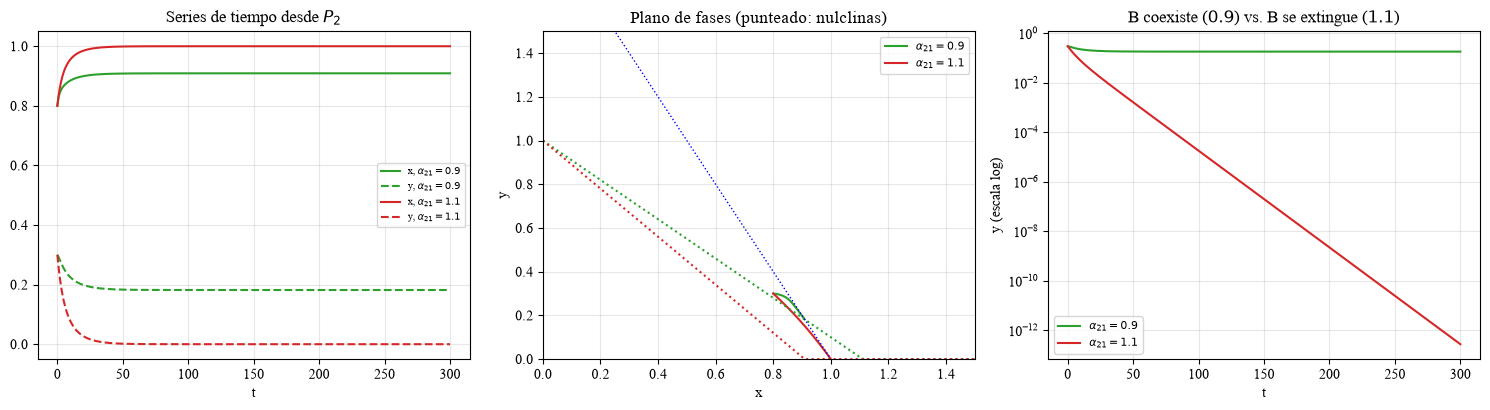

In [21]:
def campo_p(a12_, a21_):
    return lambda t, X: np.array([r1 * X[0] * (1 - X[0] - a12_ * X[1]),
                                  r2 * X[1] * (1 - X[1] - a21_ * X[0])])


fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for a21_, c in [(0.9, 'tab:green'), (1.1, 'tab:red')]:
    fp = campo_p(a12, a21_)
    tt, Xc = rk4(fp, P['P2'], 0.05, 300)
    axs[0].plot(tt, Xc[:, 0], '-', color=c, label=rf'x, $\alpha_{{21}}={a21_}$')
    axs[0].plot(tt, Xc[:, 1], '--', color=c, label=rf'y, $\alpha_{{21}}={a21_}$')
    axs[1].plot(Xc[:, 0], Xc[:, 1], color=c, label=rf'$\alpha_{{21}}={a21_}$')
    print(f"a21 = {a21_}: estado final (T=300) = ({Xc[-1,0]:.5f}, {Xc[-1,1]:.5f});  y*(teórico) = {(1-a21_)/(1-a12*a21_):.4f}")
axs[0].set_xlabel('t'); axs[0].set_title('Series de tiempo desde $P_2$'); axs[0].legend(fontsize=7); axs[0].grid(alpha=0.3)
xx = np.linspace(0, 1.5, 200)
for a21_, c in [(0.9, 'tab:green'), (1.1, 'tab:red')]:
    axs[1].plot(xx, np.clip(1 - a21_ * xx, 0, None), ':', color=c)
axs[1].plot(xx[xx <= 1], (1 - xx[xx <= 1]) / a12, 'b:', lw=1)
axs[1].set_xlim(0, 1.5); axs[1].set_ylim(0, 1.5)
axs[1].set_xlabel('x'); axs[1].set_ylabel('y'); axs[1].set_title('Plano de fases (punteado: nulclinas)')
axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
# Segundo panel: y(t) en escala logarítmica para ver el decaimiento de B
for a21_, c in [(0.9, 'tab:green'), (1.1, 'tab:red')]:
    tt, Xc = rk4(campo_p(a12, a21_), P['P2'], 0.05, 300)
    axs[2].semilogy(tt, Xc[:, 1], color=c, label=rf'$\alpha_{{21}}={a21_}$')
axs[2].set_xlabel('t'); axs[2].set_ylabel('y (escala log)'); axs[2].set_title('B coexiste ($0.9$) vs. B se extingue ($1.1$)')
axs[2].legend(fontsize=8); axs[2].grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('img/task2_critico.png', dpi=200)
plt.show()

### 2.5c – Robustez frente a $\alpha_{21}$
Se calcula, para $\alpha_{21}\in[0,1.2]$: $y^*$, $\min|\mathrm{Re}\,\lambda|$ del equilibrio estable y $T_{rec}=1/\min|\mathrm{Re}\,\lambda|$. Para $\alpha_{21}<1$ el estable es el interior; para $\alpha_{21}>1$ es $(1,0)$ (y $y^*$ físico $=0$).

  a21 |      x* |      y* | min|Re lam| |    T_rec
 0.60 |  0.7143 |  0.5714 |      0.2676 |    3.737
 0.50 |  0.6667 |  0.6667 |      0.3154 |    3.171
 0.40 |  0.6250 |  0.7500 |      0.3585 |    2.790
 0.30 |  0.5882 |  0.8235 |      0.3978 |    2.514
 0.90 |  0.9091 |  0.1818 |      0.0826 |   12.101
 0.95 |  0.9524 |  0.0952 |      0.0431 |   23.217
 0.99 |  0.9901 |  0.0198 |      0.0089 |  112.110


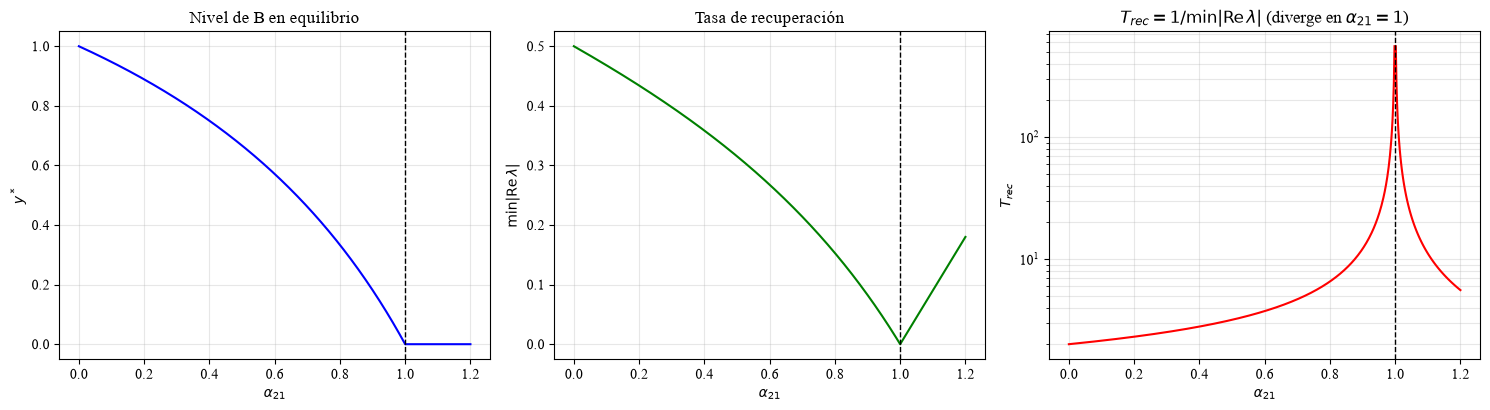

In [22]:
def jac_p(x_, y_, a12_, a21_):
    return np.array([[r1 * (1 - 2 * x_ - a12_ * y_), -r1 * a12_ * x_],
                     [-r2 * a21_ * y_, r2 * (1 - 2 * y_ - a21_ * x_)]])


def estable(a12_, a21_):
    # Devuelve (x*, y*, min|Re lambda|, T_rec) del equilibrio estable
    if a21_ < 1:
        Dd = 1 - a12_ * a21_
        px, py = (1 - a12_) / Dd, (1 - a21_) / Dd
    else:
        px, py = 1.0, 0.0
    lam = np.linalg.eigvals(jac_p(px, py, a12_, a21_)).real
    lmin = np.min(np.abs(lam))
    return px, py, lmin, (1 / lmin if lmin > 1e-12 else np.inf)


grid21 = np.linspace(0, 1.2, 601)
ys_v = np.array([estable(a12, a_)[1] for a_ in grid21])
lm_v = np.array([estable(a12, a_)[2] for a_ in grid21])
Tr_v = np.array([estable(a12, a_)[3] for a_ in grid21])

print(f"{'a21':>5s} | {'x*':>7s} | {'y*':>7s} | {'min|Re lam|':>11s} | {'T_rec':>8s}")
for a_ in (0.6, 0.5, 0.4, 0.3, 0.9, 0.95, 0.99):
    px, py, lm, Tr = estable(a12, a_)
    print(f"{a_:5.2f} | {px:7.4f} | {py:7.4f} | {lm:11.4f} | {Tr:8.3f}")

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
axs[0].plot(grid21, ys_v, 'b'); axs[0].axvline(1, color='k', ls='--', lw=1)
axs[0].set_xlabel(r'$\alpha_{21}$'); axs[0].set_ylabel('$y^*$'); axs[0].set_title('Nivel de B en equilibrio')
axs[1].plot(grid21, lm_v, 'g'); axs[1].axvline(1, color='k', ls='--', lw=1)
axs[1].set_xlabel(r'$\alpha_{21}$'); axs[1].set_ylabel(r'$\min|\mathrm{Re}\,\lambda|$'); axs[1].set_title('Tasa de recuperación')
axs[2].semilogy(grid21[grid21 < 0.999], Tr_v[grid21 < 0.999], 'r'); axs[2].semilogy(grid21[grid21 > 1.001], Tr_v[grid21 > 1.001], 'r')
axs[2].axvline(1, color='k', ls='--', lw=1)
axs[2].set_xlabel(r'$\alpha_{21}$'); axs[2].set_ylabel(r'$T_{rec}$'); axs[2].set_title(r'$T_{rec}=1/\min|\mathrm{Re}\,\lambda|$ (diverge en $\alpha_{21}=1$)')
for a_ in axs: a_.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('img/task2_robustez.png', dpi=200)
plt.show()

In [23]:
# Efecto de reducir alpha21 y de errores de estimación de +-0.1
_, y0_, _, T0_ = estable(a12, a21)
print(f"Actual a21 = {a21}: y* = {y0_:.4f}, T_rec = {T0_:.3f}")
for dlt in (0.1, 0.2):
    px, py, lm, Tr = estable(a12, a21 - dlt)
    print(f"Reducir a21 en {dlt}: a21 = {a21 - dlt:.1f} -> y* = {py:.4f} (+{py - y0_:.4f}, {100*(py/y0_-1):.1f} %), T_rec = {Tr:.3f}")
for dlt in (-0.1, 0.1):
    px, py, lm, Tr = estable(a12, a21 + dlt)
    print(f"Si el a21 verdadero es {a21 + dlt:.1f} (error {dlt:+.1f}): y* = {py:.4f}, T_rec = {Tr:.3f}")
print(f"Pendiente dy*/da21 en 0.6: {(estable(a12, 0.601)[1] - estable(a12, 0.599)[1]) / 0.002:.4f}")
print(f"Margen hasta la bifurcación: 1 - a21 = {1 - a21:.2f}; a21 verdadero tendría que ser {1 - a21:.1f} más alto que el estimado")
# alpha12: B sobrevive solo si a12 < 1 (con a21 = 0.6)
for a12_ in (0.5, 0.9, 1.0, 1.2):
    if a12_ * a21 != 1:
        Dd = 1 - a12_ * a21
        print(f"a12 = {a12_}: interior = ({(1 - a12_) / Dd:.3f}, {(1 - a21) / Dd:.3f})  (x* < 0 si a12 > 1: A no puede coexistir, B gana)")

Actual a21 = 0.6: y* = 0.5714, T_rec = 3.737
Reducir a21 en 0.1: a21 = 0.5 -> y* = 0.6667 (+0.0952, 16.7 %), T_rec = 3.171
Reducir a21 en 0.2: a21 = 0.4 -> y* = 0.7500 (+0.1786, 31.2 %), T_rec = 2.790
Si el a21 verdadero es 0.5 (error -0.1): y* = 0.6667, T_rec = 3.171
Si el a21 verdadero es 0.7 (error +0.1): y* = 0.4615, T_rec = 4.673
Pendiente dy*/da21 en 0.6: -1.0204
Margen hasta la bifurcación: 1 - a21 = 0.40; a21 verdadero tendría que ser 0.4 más alto que el estimado
a12 = 0.5: interior = (0.714, 0.571)  (x* < 0 si a12 > 1: A no puede coexistir, B gana)
a12 = 0.9: interior = (0.217, 0.870)  (x* < 0 si a12 > 1: A no puede coexistir, B gana)
a12 = 1.0: interior = (0.000, 1.000)  (x* < 0 si a12 > 1: A no puede coexistir, B gana)
a12 = 1.2: interior = (-0.714, 1.429)  (x* < 0 si a12 > 1: A no puede coexistir, B gana)
